# Credit Risk Prediction System
### Machine Learning + MySQL Integration

Author: Mangesh Nersekar  
Tools Used: Python, MySQL, Logistic Regression

## Problem Statement

Banks need to predict whether a loan applicant will default.
This project builds a machine learning model to classify loan applicants
into risk categories using Logistic Regression.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import joblib
import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv("credit_risk_dataset.csv")

print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [22]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None
         person_age  person_income  perso

In [23]:
print(df.dropna(inplace=True))
df = pd.get_dummies(df, drop_first=True)

None


EXPLORATORY DATA ANALYSIS (EDA)


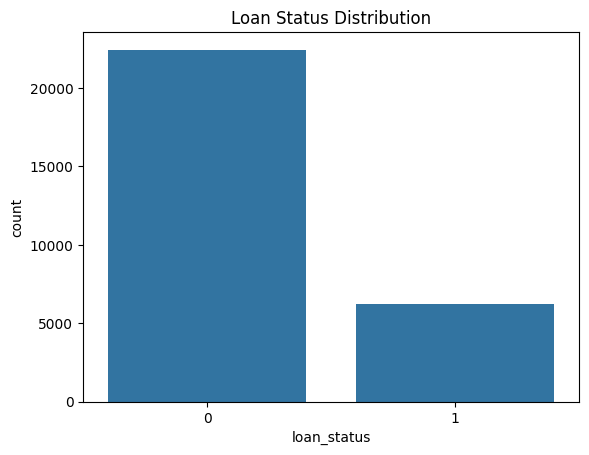

In [24]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

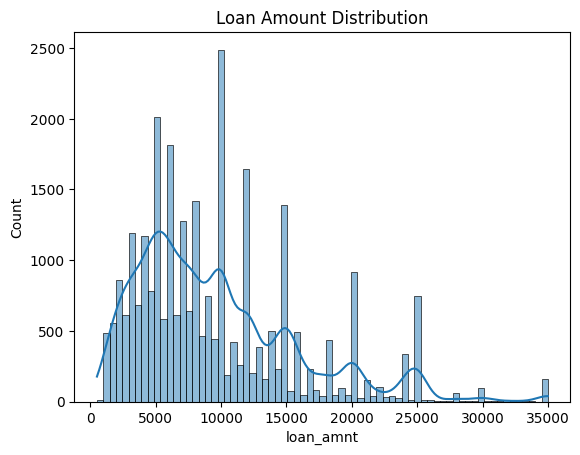

In [25]:
sns.histplot(df['loan_amnt'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

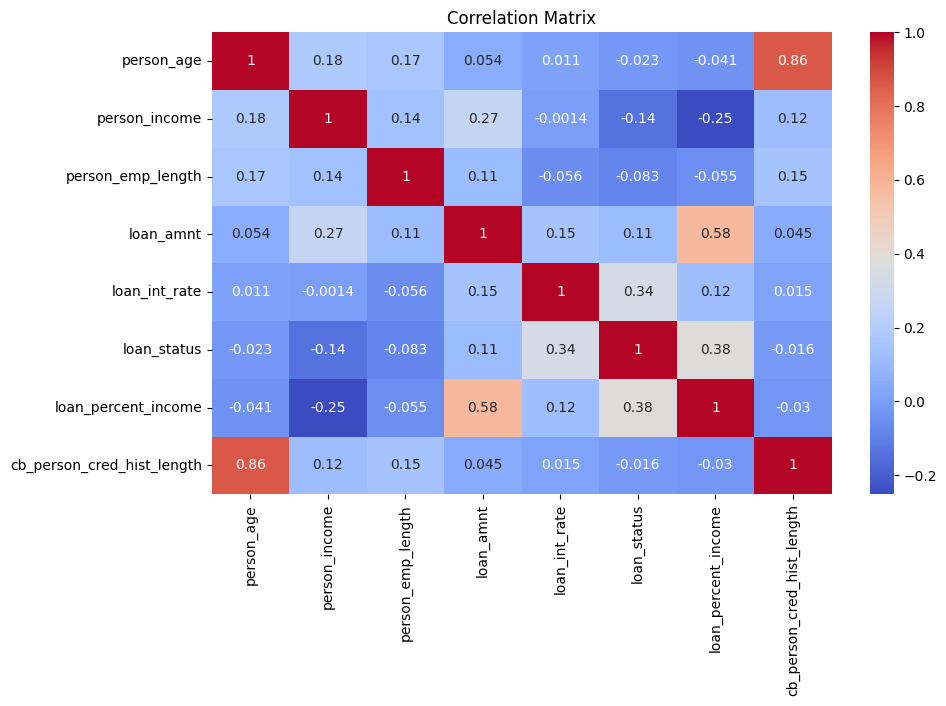

In [26]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

FEATURE & TARGET SPLIT

In [27]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred))

Accuracy: 0.7838687150837989
ROC-AUC: 0.8521351735033731
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      4443
           1       0.51      0.77      0.62      1285

    accuracy                           0.78      5728
   macro avg       0.72      0.78      0.73      5728
weighted avg       0.83      0.78      0.80      5728



CONFUSION MATRIX VISUALIZATION

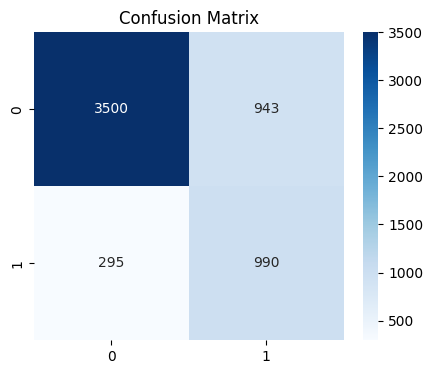

In [28]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

ROC CURVE

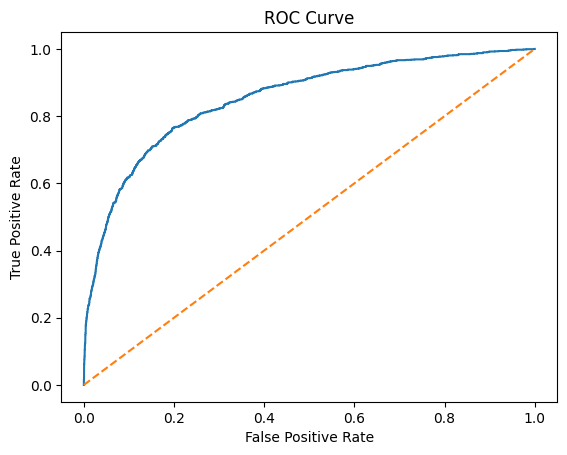

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

RISK SEGMENTATION (Business Layer)

In [30]:
df['default_probability'] = model.predict_proba(X)[:,1]

df['risk_category'] = pd.cut(
    df['default_probability'],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df[['default_probability', 'risk_category']].head()

,default_probability,risk_category
0,0.914887,High Risk
1,0.088912,Low Risk
2,0.726596,High Risk
3,0.950847,High Risk
4,0.958415,High Risk


FEATURE IMPORTANCE

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient
5,loan_percent_income,1.313400
18,loan_grade_E,0.895450
17,loan_grade_D,0.821990
9,person_home_ownership_RENT,0.675489
19,loan_grade_F,0.355152
11,loan_intent_HOMEIMPROVEMENT,0.262850
4,loan_int_rate,0.230011
20,loan_grade_G,0.202858
21,cb_person_default_on_file_Y,0.137449
7,person_home_ownership_OTHER,0.070898


SAVE MODEL

In [32]:
joblib.dump(model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

SAVE DATA WITH PREDICTIONS

In [33]:
df.to_csv("credit_risk_dataset_with_predictions.csv", index=False)